# Merge der Daten

Um nicht 3 einzelne Datensätze zu haben, wurde die Daten jedes Sensores zusammengefügt und auf einen gemeinsamen Nenner gebraucht. Um dies zu erreichen wurden die Daten jedes Sensores auf ein einheitliches Zeitfenster gesetzt und Lücken mit linearer Interpolation aufgefüllt. Mehr Dazu findet man im Unterkapitel "Vorgehen Merging" weiter unten.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
# Dateneinlesen
base_path = "../Daten"
sensors = ["Accelerometer", "Gyroscope", "Orientation"]

def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

def find_measurement_folders(base):
    """Liefert (folder_path, author).
    Author = Name des User-Unterordners (Daten/<user>/<measurement>).
    Wenn ein Mess-Ordner direkt unter Daten/ liegt (kein User zugeordnet), ist author = 'Unbekannt'.
    """
    out = []
    for entry in sorted(os.listdir(base)):
        entry_path = os.path.join(base, entry)
        if not os.path.isdir(entry_path):
            continue
        if os.path.exists(os.path.join(entry_path, "Tags.csv")):
            out.append((entry_path, "Unbekannt"))
        else:
            for sub in sorted(os.listdir(entry_path)):
                sub_path = os.path.join(entry_path, sub)
                if os.path.isdir(sub_path) and os.path.exists(os.path.join(sub_path, "Tags.csv")):
                    out.append((sub_path, entry))
    return out

raw_dfs = {sensor: [] for sensor in sensors}
measurement_id = 0

for folder_path, author in find_measurement_folders(base_path):
    try:
        tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))

        for sensor in sensors:
            data = pd.read_csv(os.path.join(folder_path, f"{sensor}.csv"))
            data["Sensor"] = sensor
            data["time"] = pd.to_datetime(data["time"])
            data["Tag"] = tag["tag"].iloc[0]
            data["ID"] = measurement_id
            data["Author"] = author
            raw_dfs[sensor].append(data)

    except Exception as e:
        print(f"Fehler in Ordner {folder_path}: {e}")

    measurement_id += 1  # einmal pro Ordner, nicht pro Sensor

# Zusammenfuehren und trimmen
dfs = {}
for sensor in sensors:
    raw = pd.concat(raw_dfs[sensor], ignore_index=True)
    raw["ID_backup"] = raw["ID"]
    dfs[sensor] = (
        raw
        .groupby("ID_backup", group_keys=False)
        .apply(trim_measurement)
        .reset_index(drop=True)
    )

# Zugriff auf die einzelnen DataFrames
acc_df  = dfs["Accelerometer"]
gyr_df  = dfs["Gyroscope"]
ori_df  = dfs["Orientation"]

C:\Users\jessi\AppData\Local\Temp\ipykernel_19352\969068707.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(trim_measurement)
C:\Users\jessi\AppData\Local\Temp\ipykernel_19352\969068707.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(trim_measurement)
C:\Users\jessi\AppData\Local\Temp\ipykernel_19352\969068707.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This 

In [5]:
print("Accelerometer-Size:", acc_df.shape)
print("Gyroscope-Size:", gyr_df.shape)
print("Orientation-Size:", ori_df.shape)

Accelerometer-Size: (3077151, 10)
Gyroscope-Size: (2815304, 10)
Orientation-Size: (2984074, 14)


In [6]:
print("Accelerometer columns:", acc_df.columns)
print("Gyroscope columns:", gyr_df.columns)
print("Orientation columns:", ori_df.columns)

Accelerometer columns: Index(['time', 'seconds_elapsed', 'z', 'y', 'x', 'Sensor', 'Tag', 'ID',
       'Author', 'ID_backup'],
      dtype='object')
Gyroscope columns: Index(['time', 'seconds_elapsed', 'z', 'y', 'x', 'Sensor', 'Tag', 'ID',
       'Author', 'ID_backup'],
      dtype='object')
Orientation columns: Index(['time', 'seconds_elapsed', 'qz', 'qy', 'qx', 'qw', 'roll', 'pitch',
       'yaw', 'Sensor', 'Tag', 'ID', 'Author', 'ID_backup'],
      dtype='object')


In [7]:
# Verwendete Freqeunzen pro Sensor und pro Aufnahme
for name, df in [("Accelerometer", acc_df), ("Gyroscope", gyr_df), ("Orientation", ori_df)]:
    print(f"\n{name}:")
    summary = (
        df.groupby("ID")["seconds_elapsed"]
        .agg(
            Anzahl_Zeilen="count",
            Avg_Diff=lambda x: x.sort_values().diff().mean()
        )
        .reset_index()
    )
    summary["Frequenz_Hz"] = (1 / summary["Avg_Diff"]).round(1)
    print(summary)


Accelerometer:
      ID  Anzahl_Zeilen  Avg_Diff  Frequenz_Hz
0      0           3508  0.008673        115.3
1      1           1297  0.008673        115.3
2      2           1151  0.008673        115.3
3      3           1627  0.008673        115.3
4      4           3355  0.008673        115.3
..   ...            ...       ...          ...
822  822           1459  0.008452        118.3
823  823           1597  0.008451        118.3
824  824           1360  0.008459        118.2
825  825           1578  0.008457        118.2
826  826           1181  0.008451        118.3

[827 rows x 4 columns]

Gyroscope:
      ID  Anzahl_Zeilen  Avg_Diff  Frequenz_Hz
0      0           3508  0.008673        115.3
1      1           1298  0.008673        115.3
2      2           1151  0.008673        115.3
3      3           1627  0.008673        115.3
4      4           3355  0.008673        115.3
..   ...            ...       ...          ...
822  822           1457  0.008458        118.2
823  823

## Vorgehen Merging

Da die drei Sensoren teilweise unterschiedliche Aufnahmefrequenzen haben, besitzen sie unterschiedlich viele Zeilen pro Aufnahme. Um alle Sensoren in einen gemeinsamen Datensatz zusammenzuführen, wird ein einheitliches Zeitraster von 0.02s (50Hz) verwendet.

Dabei wird die Zeit jeder Aufnahme (ID) auf 0 normiert, sodass jede Aufnahme bei t=0 beginnt. Anschliessend werden alle Messwerte innerhalb eines 0.02s-Fensters zum Mittelwert aggregiert (Downsampling von ~115Hz auf 50Hz). Da Accelerometer und Gyroscope beide Spalten mit den Namen x, y und z besitzen, werden diese vor dem Zusammenführen umbenannt (z.B. x_acc, x_gyr), um Verwechslungen zu vermeiden.

15ms sind zu klein, da so noch mehr NAs entstehen. 

In [8]:
def resample_sensor(df, sensor_cols, freq="25ms"):
    result = []
    for id_, group in df.groupby("ID"):
        tag    = group["Tag"].iloc[0]
        author = group["Author"].iloc[0]
        # Auf 0 normieren
        elapsed_normalized = group["seconds_elapsed"] - group["seconds_elapsed"].min()
        group = group.set_index(
            pd.to_timedelta(elapsed_normalized, unit="s")
        )[sensor_cols]
        group = group.resample(freq).mean()
        group["ID"]     = id_
        group["Tag"]    = tag
        group["Author"] = author
        result.append(group)
    return pd.concat(result).reset_index(names="time_elapsed")

acc_rs  = resample_sensor(acc_df,  ["x", "y", "z"])
gyr_rs  = resample_sensor(gyr_df,  ["x", "y", "z"])
ori_rs  = resample_sensor(ori_df,  ["qx", "qy", "qz", "qw", "roll", "pitch", "yaw"])

# Spalten umbenennen vor dem Merge
acc_rs = acc_rs.rename(columns={"x": "x_acc", "y": "y_acc", "z": "z_acc"})
gyr_rs = gyr_rs.rename(columns={"x": "x_gyr", "y": "y_gyr", "z": "z_gyr"})

# Zusammenfuehren
merged_df = (
    acc_rs
    .merge(gyr_rs, on=["time_elapsed", "ID", "Tag", "Author"])
    .merge(ori_rs,  on=["time_elapsed", "ID", "Tag", "Author"])
)

print(merged_df.shape)
print(merged_df.head())

(1055056, 17)
            time_elapsed     x_acc     y_acc     z_acc  ID     Tag  \
0        0 days 00:00:00  7.220327 -2.509777 -3.261837   0  Laufen   
1 0 days 00:00:00.025000  4.125708 -5.508441 -3.403136   0  Laufen   
2 0 days 00:00:00.050000 -3.260518 -2.079975 -3.495848   0  Laufen   
3 0 days 00:00:00.075000 -5.160624  1.425919 -1.204314   0  Laufen   
4 0 days 00:00:00.100000 -1.981047  2.735377  0.025065   0  Laufen   

           Author     x_gyr     y_gyr     z_gyr        qx        qy        qz  \
0  Jessica_Schmid  1.899331  0.997033  0.691957 -0.719674 -0.113393  0.076918   
1  Jessica_Schmid  1.640325  1.184772  0.291433 -0.707831 -0.103070  0.072057   
2  Jessica_Schmid  1.005433  1.381674  0.311999 -0.701441 -0.082747  0.064866   
3  Jessica_Schmid  0.623642  0.726216  0.720668 -0.698580 -0.070737  0.068146   
4  Jessica_Schmid  0.590655  0.239968  0.857298 -0.694715 -0.060853  0.073490   

         qw      roll     pitch       yaw  
0  0.680626 -2.513721  1.494964  2

In [9]:
# haben wir alle Aufnahmen
print(merged_df["ID"].nunique())

827


In [10]:
# konvertieren des Datentypes für die Zeitpunkte
merged_df["time_elapsed"] = merged_df["time_elapsed"].dt.total_seconds()
print(merged_df.head())

   time_elapsed     x_acc     y_acc     z_acc  ID     Tag          Author  \
0         0.000  7.220327 -2.509777 -3.261837   0  Laufen  Jessica_Schmid   
1         0.025  4.125708 -5.508441 -3.403136   0  Laufen  Jessica_Schmid   
2         0.050 -3.260518 -2.079975 -3.495848   0  Laufen  Jessica_Schmid   
3         0.075 -5.160624  1.425919 -1.204314   0  Laufen  Jessica_Schmid   
4         0.100 -1.981047  2.735377  0.025065   0  Laufen  Jessica_Schmid   

      x_gyr     y_gyr     z_gyr        qx        qy        qz        qw  \
0  1.899331  0.997033  0.691957 -0.719674 -0.113393  0.076918  0.680626   
1  1.640325  1.184772  0.291433 -0.707831 -0.103070  0.072057  0.695075   
2  1.005433  1.381674  0.311999 -0.701441 -0.082747  0.064866  0.704922   
3  0.623642  0.726216  0.720668 -0.698580 -0.070737  0.068146  0.708747   
4  0.590655  0.239968  0.857298 -0.694715 -0.060853  0.073490  0.712923   

       roll     pitch       yaw  
0 -2.513721  1.494964  2.243559  
1 -2.071503  1.522

In [11]:
merged_df.isna().sum()

time_elapsed      0
x_acc           269
y_acc           269
z_acc           269
ID                0
Tag               0
Author            0
x_gyr           218
y_gyr           218
z_gyr           218
qx               76
qy               76
qz               76
qw               76
roll             76
pitch            76
yaw              76
dtype: int64

## Interpolation NAs
Je nach Frequenz sind die NA Zahlen tiefer. Eine tiefere Frequenz hat weniger NAs. Als Lösung für das Problem mit den NAs wird eine Lineare Interpolation angewendet. 

In [12]:
sensor_cols = ["x_acc", "y_acc", "z_acc", "x_gyr", "y_gyr", "z_gyr",
               "qx", "qy", "qz", "qw", "roll", "pitch", "yaw"]

merged_df[sensor_cols] = (
    merged_df
    .groupby("ID")[sensor_cols]     # groupby since it should only interpolate within one ID
    .transform(lambda x: x.interpolate(method="linear", limit_direction="both"))
)

In [13]:
print(merged_df[sensor_cols].isna().sum())

x_acc    0
y_acc    0
z_acc    0
x_gyr    0
y_gyr    0
z_gyr    0
qx       0
qy       0
qz       0
qw       0
roll     0
pitch    0
yaw      0
dtype: int64


In [14]:
# export data as parquet for modeling
merged_df.to_parquet("../Model_data/merged_df_40Hz.parquet", index=False)

## Achsenausrichtung

Um zu sehen, ob Accelerometer und Gyroscope die gleichen Ausrichtungen für x, y und z haben, werden verschiedene Plots erstellt. Da das Gyproscope die Winkelgeschwindigkeit und das Accelerometer die Beschleunigung ist, sollten die Linien einem ähnlichen Muster folgen, mit einem kurzen Lag dazwischen. 

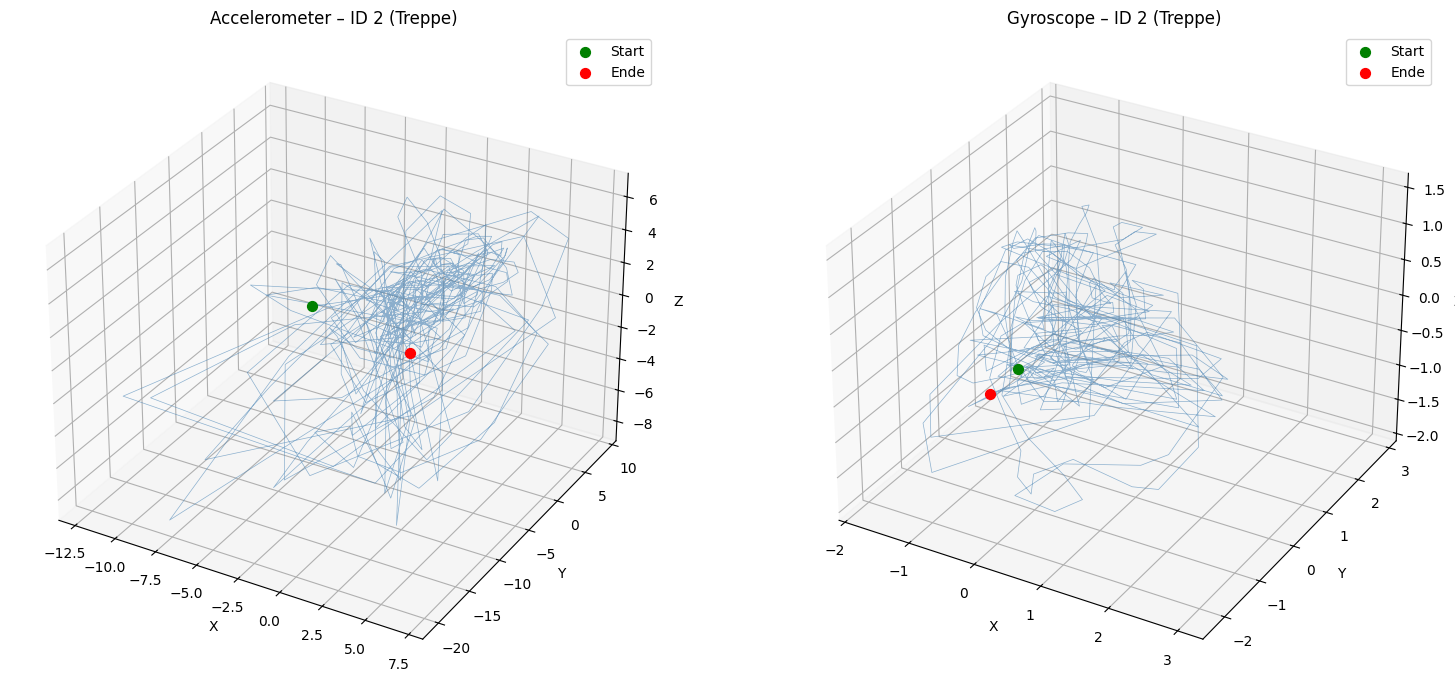

In [15]:
id_to_plot = 2
data = merged_df[merged_df["ID"] == id_to_plot]

fig = plt.figure(figsize=(16, 7))

for i, (sensor, cols) in enumerate([
    ("Accelerometer", ("x_acc", "y_acc", "z_acc")),
    ("Gyroscope",     ("x_gyr", "y_gyr", "z_gyr"))
], start=1):
    ax = fig.add_subplot(1, 2, i, projection='3d')
    x, y, z = data[cols[0]], data[cols[1]], data[cols[2]]
    
    # Linie für den Verlauf
    ax.plot(x, y, z, lw=0.5, alpha=0.6, color="steelblue")
    # Start- und Endpunkt markieren
    ax.scatter(*[v.iloc[0] for v in (x, y, z)], color="green", s=50, zorder=5, label="Start")
    ax.scatter(*[v.iloc[-1] for v in (x, y, z)], color="red",   s=50, zorder=5, label="Ende")
    
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"{sensor} – ID {id_to_plot} ({data['Tag'].iloc[0]})")
    ax.legend()

plt.tight_layout()
plt.show()

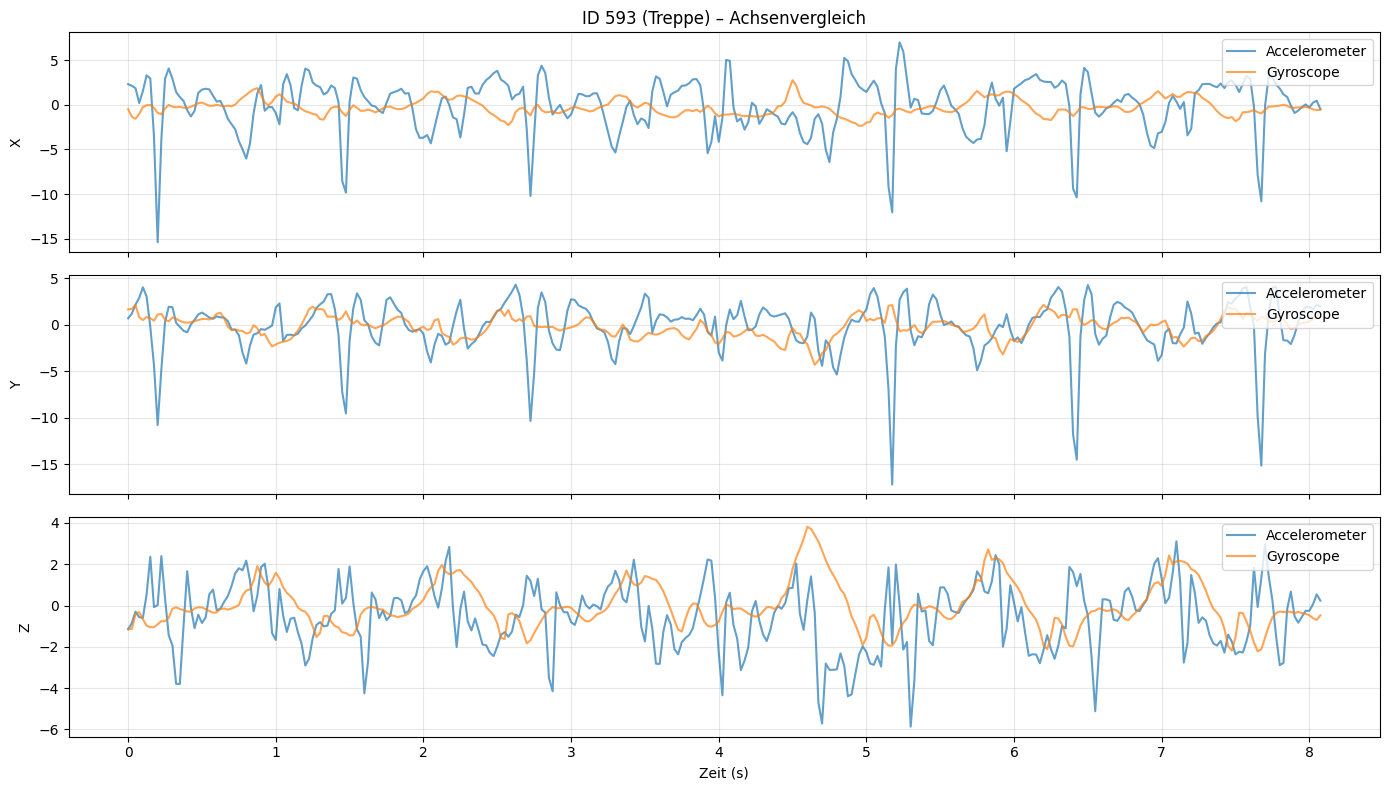

In [38]:
id_to_plot = 593
data = merged_df[merged_df["ID"] == id_to_plot]
time = data["time_elapsed"]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, axis in zip(axes, ["x", "y", "z"]):
    ax.plot(time, data[f"{axis}_acc"], label="Accelerometer", alpha=0.7)
    ax.plot(time, data[f"{axis}_gyr"], label="Gyroscope",     alpha=0.7)
    ax.set_ylabel(axis.upper())
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[0].set_title(f"ID {id_to_plot} ({data['Tag'].iloc[0]}) – Achsenvergleich")
axes[2].set_xlabel("Zeit (s)")
plt.tight_layout()
plt.show()

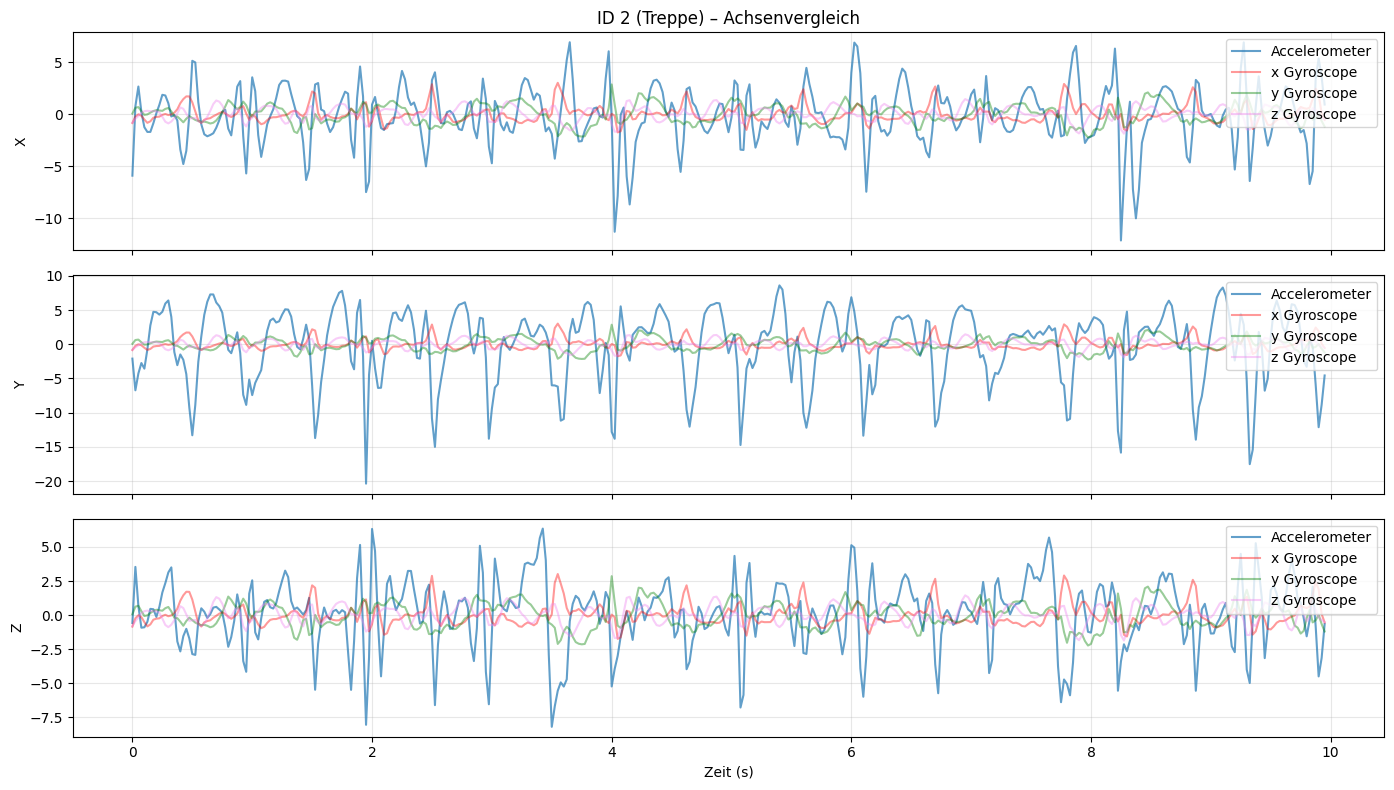

In [ ]:
id_to_plot = 2
data = merged_df[merged_df["ID"] == id_to_plot]
time = data["time_elapsed"]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, axis in zip(axes, ["x", "y", "z"]):
    ax.plot(time, data[f"{axis}_acc"], label="Accelerometer", alpha=0.7)
    ax.plot(time, data[f"x_gyr"], label="x Gyroscope", alpha=0.4, color="red"), 
    ax.plot(time, data[f"y_gyr"], label="y Gyroscope", alpha=0.4, color="green")
    ax.plot(time, data[f"z_gyr"], label="z Gyroscope", alpha=0.4, color="violet")
    ax.set_ylabel(axis.upper())
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[0].set_title(f"ID {id_to_plot} ({data['Tag'].iloc[0]}) – Achsenvergleich")
axes[2].set_xlabel("Zeit (s)")
plt.tight_layout()
plt.show()

Basierend auf den Plots sollten es die gleichen Ausrichtungen sein für die jeweiligen Sensoren. 